# Authorship analysis

Analyses authorship of the non-conceptual papers in `data-clean/all-data.csv`, in particular
the overlap of authors between the AGILE and GIScience conference series.

For every paper we resolve the DOI from the `link` column and query **OpenAlex** (via `pyalex`)
to obtain authors and their ORCIDs. Authors are then reconciled across papers, preferring ORCID
over author name (so that a person who changed their name is still matched to a single identity),
with a normalised-name fallback for authors without an ORCID.

OpenAlex misses a handful of registered DOIs (notably Dagstuhl LIPIcs entries). For those we fall
back to an OpenAlex title search (checking the work's `locations[]` list for parallel hostings)
and, as a last resort, to scraping schema.org `ScholarlyArticle` metadata from the publisher
landing page HTML head.

Conceptual papers (`consolidated_cp == True`) are excluded.

Raw JSON responses are cached under `data/authorship-cache/` to keep re-runs cheap; the
cache is git-ignored.

### Related work

Earlier work by Keßler, Janowicz, and Kauppinen explored the GIScience research field through
linked data built from conference metadata: *spatial@linkedscience -- Exploring the Research
Field of GIScience with Linked Data*, GIScience 2012 (LNCS 7478),
[doi:10.1007/978-3-642-33024-7_8](https://doi.org/10.1007/978-3-642-33024-7_8). That work
established a linked-data view of the community that complements the paper-level authorship
reconciliation pursued here.

## 1. Setup

All dependencies are declared in [`04_environment.yml`](04_environment.yml): the conda packages
`matplotlib-base`, `matplotlib-venn`, and `requests` (already present from the base env), plus
`pyalex` via pip.

Helper functions live in [`authorship_utils.py`](authorship_utils.py) next to this notebook --
DOI extraction, OpenAlex fetching with on-disk caching, schema.org JSON-LD landing-page
fallback, title similarity, author normalisation, and identity resolution.

In [185]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyalex
from matplotlib_venn import venn2

import authorship_utils as au

MAILTO = "daniel.nuest@tu-dresden.de"
pyalex.config.email = MAILTO

USER_AGENT = (
    f"reproducible-research-giscience-longitudinal-study/1.0 (mailto:{MAILTO})"
)

INPUT_CSV = "data-clean/all-data.csv"
CACHE_DIR = Path("data/authorship-cache")
OPENALEX_CACHE = CACHE_DIR / "openalex"
OPENALEX_CACHE.mkdir(parents=True, exist_ok=True)

FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 120)

## 2. Load and filter papers

Drop conceptual papers as requested; only `consolidated_cp == False` is considered.

In [186]:
df_all = pd.read_csv(INPUT_CSV)
df = df_all[df_all["consolidated_cp"] == False].copy().reset_index(drop=True)
print(f"total papers: {len(df_all)}")
print(f"non-conceptual papers analysed: {len(df)}")
print(df.groupby("conf").size())

total papers: 224
non-conceptual papers analysed: 203
conf
agile        130
giscience     73
dtype: int64


## 3. Resolve DOIs from the `link` column

The `link` column contains a mix of forms:

- `https://doi.org/...` -- use directly.
- Springer `.../chapter/10.XXXX/...` -- the DOI is the tail starting at `10.`.
- Copernicus `agile-giss.copernicus.org/articles/{vol}/{art}/{year}/` -- assemble
  `10.5194/agile-giss-{vol}-{art}-{year}`.
- Dagstuhl `drops.dagstuhl.de/.../LIPIcs.GIScience.{year}.{n}/...` -- assemble
  `10.4230/LIPIcs.GIScience.{year}.{n}`.
- Anything else is logged as unresolved.

In [187]:
df["doi"] = df["link"].map(au.extract_doi)
missing = df[df["doi"].isna()][["paper", "link"]]
print(f"DOIs resolved: {df['doi'].notna().sum()} / {len(df)}")
if not missing.empty:
    print("\nUnresolved links:")
    display(missing)

DOIs resolved: 203 / 203


## 4. Fetch metadata from OpenAlex

Each paper's JSON payload is cached on disk so re-runs are offline. Delete
`data/authorship-cache/` to force a refresh.

OpenAlex fetches try, in order:

1. **Direct DOI lookup** via `pyalex.Works()[doi_url]`.
2. **Title-search fallback** when (1) returns 404, accepting a candidate if its primary DOI
   matches, if the registered DOI appears in the candidate's `locations[]` list (parallel
   hostings: preprints, repositories, re-publications), or if title similarity and year match
   strongly.
3. **Landing-page JSON-LD scrape** when (2) also fails, parsing the publisher's schema.org
   `ScholarlyArticle` metadata from `<script type="application/ld+json">`. This covers the
   cases where a DOI is not indexed by OpenAlex at all (e.g. Dagstuhl LIPIcs pages serve rich
   schema.org metadata including ORCIDs as `sameAs`).

Transient API errors are retried a few times before giving up.

In [188]:
# Thin wrapper binds the fetch helper to this notebook's cache dir and user agent.
def fetch_openalex(doi, title, year):
    return au.fetch_openalex(
        doi, OPENALEX_CACHE,
        expected_title=title, expected_year=year,
        landing_page_url=f"https://doi.org/{doi}",
        landing_page_user_agent=USER_AGENT,
    )

In [189]:
openalex_data: dict[str, dict] = {}

for i, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    if i % 25 == 0:
        print(f"[{i+1}/{len(df)}] {row['paper']} -> {doi}")
    openalex_data[doi] = fetch_openalex(doi, row["title"], int(row["year"])) or {}

oa_found = sum(1 for v in openalex_data.values() if v and not v.get("_not_found"))
recovered = sum(1 for v in openalex_data.values() if v and v.get("_recovered_via"))
print(f"\nOpenAlex hits: {oa_found} / {len(openalex_data)}  (of which {recovered} via fallback)")

recovered_rows = [
    {"doi": doi, "recovered_via": v.get("_recovered_via"), "openalex_doi": v.get("doi")}
    for doi, v in openalex_data.items()
    if v and v.get("_recovered_via")
]
if recovered_rows:
    display(pd.DataFrame(recovered_rows))

[1/203] agile_2017_006 -> 10.1007/978-3-319-56759-4_6
[26/203] giscience_2021_024 -> 10.4230/lipics.giscience.2021.ii.8
[51/203] giscience_2021_017 -> 10.4230/lipics.giscience.2021.ii.1
[76/203] giscience_2021_019 -> 10.4230/lipics.giscience.2021.ii.3
[101/203] giscience_2021_014 -> 10.4230/lipics.giscience.2021.i.14
[126/203] giscience_2018_015 -> 10.4230/LIPIcs.GIScience.2018.15
[151/203] giscience_2021_012 -> 10.4230/lipics.giscience.2021.i.12
[176/203] giscience_2021_029 -> 10.4230/lipics.giscience.2021.ii.13
[201/203] giscience_2021_018 -> 10.4230/lipics.giscience.2021.ii.2

OpenAlex hits: 203 / 203  (of which 11 via fallback)


,doi,recovered_via,openalex_doi
0,10.5194/agile-giss-4-3-2023,doi-exact,https://doi.org/10.5194/agile-giss-4-3-2023
1,10.4230/LIPIcs.GIScience.2018.8,doi-exact,https://doi.org/10.4230/lipics.giscience.2018.8
2,10.4230/lipics.giscience.2021.i.17,doi-exact,https://doi.org/10.4230/lipics.giscience.2021.i.17
3,10.4230/lipics.giscience.2021.i.2,landing-page-jsonld,https://doi.org/10.4230/lipics.giscience.2021.i.2
4,10.5194/agile-giss-1-2-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-2-2020
5,10.4230/lipics.giscience.2021.i.6,doi-in-locations,https://doi.org/10.4230/lipics.cosit.2022.1
6,10.5194/agile-giss-3-3-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-3-2022
7,10.5194/agile-giss-3-19-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-19-2022
8,10.4230/lipics.giscience.2021.i.4,doi-in-locations,https://doi.org/10.20944/preprints202002.0326.v1
9,10.5194/agile-giss-1-12-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-12-2020


## 5. Verify paper title against OpenAlex

Fuzzy match on lowercased, punctuation-stripped titles; below 0.80 similarity is flagged.
The recorded `title` in `all-data.csv` stays authoritative -- this is a sanity check that the
DOI we resolved points to the same paper.

In [190]:
verify_rows = []
for _, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    oa = openalex_data.get(doi) or {}
    oa_title = au.openalex_title(oa)
    verify_rows.append(
        {
            "paper": row["paper"],
            "title": row["title"],
            "doi": doi,
            "openalex_title": oa_title,
            "sim_openalex": au.title_similarity(row["title"], oa_title),
        }
    )

verify_df = pd.DataFrame(verify_rows)
low_match = verify_df[verify_df["sim_openalex"] < 0.80]
print(f"Titles with similarity <0.80: {len(low_match)} / {len(verify_df)}")
display(low_match.sort_values("sim_openalex"))

Titles with similarity <0.80: 1 / 203


,paper,title,doi,openalex_title,sim_openalex
116,agile_2022_011,Machine Learning with Kay,10.5194/agile-giss-3-11-2022,Machine Learning with &amp;lt;i&amp;gt;Kay&amp;lt;/i&amp;gt;,0.609756


## 6. Extract authors and ORCIDs

Per paper we read the OpenAlex `authorships[]` list in its native order, capturing the display
name and ORCID (if any) for each author.

In [191]:
author_rows = []

for _, row in df.iterrows():
    doi = row["doi"]
    oa_list = au.openalex_authors(openalex_data.get(doi) or {})
    for position, a in enumerate(oa_list, start=1):
        author_rows.append(
            {
                "paper": row["paper"],
                "conf": row["conf"],
                "year": row["year"],
                "doi": doi,
                "position": position,
                "name": a["name"],
                "orcid": a["orcid"],
            }
        )

authors_df = pd.DataFrame(author_rows)
print(f"author-paper rows: {len(authors_df)}")
print(f"papers with at least one author: {authors_df['paper'].nunique()}")
print(
    f"ORCID coverage: {authors_df['orcid'].notna().sum()} / {len(authors_df)} "
    f"({authors_df['orcid'].notna().mean():.1%})"
)

author-paper rows: 715
papers with at least one author: 203
ORCID coverage: 571 / 715 (79.9%)


## 7. Build author identities

Identity rule: ORCID is preferred (covers name changes). For authors without an ORCID in
the OpenAlex record, we use a normalised-name key.

A second pass then upgrades name-only identities to ORCID identities whenever an ORCID row
for the same normalised name exists somewhere in the corpus -- that fixes the common case
of an author appearing as ORCID-tagged on one paper and untagged on another. When two
different ORCIDs share a normalised name (i.e. genuine namesakes), the merge is skipped to
avoid collapsing two different people.

The remaining pure name-only identities can still split a single person who appears under
different name spellings, and can conflate two people with identical names -- both are
reported in the counts below so readers can reason about the error bar.

In [192]:
# Two-pass identity resolution:
# 1. ORCID-first identity per row (from OpenAlex).
# 2. Post-hoc merge: upgrade name-only identities to ORCID identities when an ORCID row
#    for the same normalised name exists in the corpus, OR when a manual decision
#    has been recorded in data/orcid-resolutions.csv (see the optional cell below).
ORCID_DECISIONS = Path("data/orcid-resolutions.csv")
decisions_df = pd.read_csv(ORCID_DECISIONS) if ORCID_DECISIONS.exists() else None

authors_df["identity"] = au.merge_name_only_identities(
    authors_df["orcid"], authors_df["name"], manual_resolutions=decisions_df,
)

id_to_name = (
    authors_df.groupby("identity")["name"]
    .agg(lambda s: Counter(s).most_common(1)[0][0])
    .to_dict()
)

n_total = authors_df["identity"].nunique()
n_orcid = sum(1 for i in authors_df["identity"].unique() if i.startswith("orcid:"))
n_name = n_total - n_orcid
n_manual = (decisions_df["chosen_orcid"].astype(str).str.upper() != "NONE").sum() if decisions_df is not None else 0
print(f"distinct author identities: {n_total}")
print(f"  - with ORCID (incl. merged name-only rows): {n_orcid}")
print(f"  - name-fallback only:                        {n_name}")
print(f"  - manual resolutions in effect:              {n_manual}")

distinct author identities: 519
  - with ORCID (incl. merged name-only rows): 425
  - name-fallback only:                        94
  - manual resolutions in effect:              23


### Optional: resolve remaining name-only identities against ORCID

Many remaining name-only identities are people who simply did not list an ORCID on a
particular paper. The workflow below queries the **ORCID public API** for matching profiles
and lets you attach each name to a specific ORCID (or mark it explicitly as "no match").
Decisions are stored in [`data/orcid-resolutions.csv`](data/orcid-resolutions.csv); the file
is committed to git so resolutions are persistent and consulted by the identity-merge cell
above on every subsequent run.

The review is split into two non-blocking notebook cells (with a manual edit step in
between) so it works in every Jupyter frontend (JupyterLab, VS Code, Cursor, nbclassic) --
no `input()` prompt, no blocked kernel:

1. **Prepare & display.** The first cell queries ORCID for every undecided name-only
   identity, writes a CSV template at [`data/orcid-candidates.csv`](data/orcid-candidates.csv),
   and renders each queue item as Markdown with **clickable DOI links** (so you can open
   the landing page of every paper the author appears on in our corpus, alongside the
   paper title) and **clickable ORCID links** (so you can open each candidate profile
   directly). Each candidate is prefixed with its 1-based index `[1]`, `[2]`, ... so you
   can refer to it by number in the next step.
2. **Record decisions.** Edit `data/orcid-candidates.csv` in-place: set the
   `chosen_orcid` column to one of

   - a **1-based candidate index** (`1`, `2`, ...) -- easiest to type when picking from
     the rendered list above; the apply cell looks the index up in the row's
     `candidate_orcids` column and records the corresponding full ORCID,
   - a **full ORCID** (`0000-0001-2345-6789`) -- equivalent, useful when copy-pasting
     from an external source (e.g. from the ORCID profile page you opened via the
     clickable link),
   - `NONE` -- no match (prevents re-querying on the next run),
   - leave blank -- skip for now (row stays in the template and re-appears next run).

   Optional free-text in `notes`. Invalid values (e.g. an out-of-range index or a
   malformed ORCID) are rejected by the apply cell with a clear error, so typos can't
   be silently recorded as a decision.
3. **Apply.** The second cell validates the template, appends the decisions to
   `data/orcid-resolutions.csv`, then re-run the identity cell above to apply them.
   Rows whose `name_key` is already present in the decisions file are skipped, so the
   apply cell is safe to re-run.

The whole block does nothing unless `RUN_ORCID_RESOLUTION` is `True`, because the manual
edit step should not run during automated notebook execution.

In [193]:
RUN_ORCID_RESOLUTION = True  # set to False to skip the ORCID review entirely
ORCID_CANDIDATES = Path("data/orcid-candidates.csv")

# Step 1 of 3: build the queue and render it with clickable DOI and ORCID links.
# This cell is safe to re-run -- partially filled-in values in orcid-candidates.csv
# are preserved when the template is regenerated.
if RUN_ORCID_RESOLUTION:
    orcid_queue = au.prepare_orcid_resolution(
        authors_df,
        df,                       # papers_df: provides the paper titles for display
        decisions_path=ORCID_DECISIONS,
        candidates_path=ORCID_CANDIDATES,
        user_agent=USER_AGENT,
        cache_dir=CACHE_DIR,      # caches ORCID API responses under data/authorship-cache/orcid/
        only_cross_year=False,     # set False to walk every name-only identity
    )
    au.display_orcid_resolution(orcid_queue, candidates_path=ORCID_CANDIDATES)

*Nothing to resolve — all eligible name-only identities already have a recorded decision.*

In [194]:
# Step 3 of 3: apply the decisions you entered into data/orcid-candidates.csv.
# Reads the template, validates each `chosen_orcid` (ORCID or 'NONE'), and appends
# to data/orcid-resolutions.csv. Idempotent -- rows already in the decisions file
# are skipped. Re-run the identity cell above afterwards to merge the new resolutions.
if RUN_ORCID_RESOLUTION and ORCID_CANDIDATES.exists():
    au.apply_orcid_resolutions(ORCID_CANDIDATES, ORCID_DECISIONS)

applied 0 new decision(s); 0 row(s) left unresolved (blank `chosen_orcid` — kept in orcid-candidates.csv); 0 row(s) already in the decisions file; decisions file now has 117 total row(s).


## 8. Part A -- Overlap over the whole corpus

This part treats each conference as a single set of author identities pooled across **all** years
in the corpus. Results here answer *"how much does the AGILE author community overlap with the
GIScience author community at all, irrespective of timing?"*. Temporal dynamics are deferred to
Part B.

### A.1 Distinct authors per conference and the intersection

In [195]:
agile_ids = set(authors_df[authors_df["conf"] == "agile"]["identity"])
gis_ids = set(authors_df[authors_df["conf"] == "giscience"]["identity"])
both_ids = agile_ids & gis_ids

print(f"AGILE-only authors:     {len(agile_ids - gis_ids)}")
print(f"GIScience-only authors: {len(gis_ids - agile_ids)}")
print(f"In both conferences:    {len(both_ids)}")

both_orcid = {i for i in both_ids if i.startswith("orcid:")}
both_name = both_ids - both_orcid
print(
    f"  of which matched by ORCID:        {len(both_orcid)}"
)
print(
    f"  of which matched by name-fallback: {len(both_name)}  (interpret with care)"
)

AGILE-only authors:     314
GIScience-only authors: 167
In both conferences:    38
  of which matched by ORCID:        37
  of which matched by name-fallback: 1  (interpret with care)


### A.2 Figure 1: Venn diagram

Distinct author identities per conference, pooled across all years.

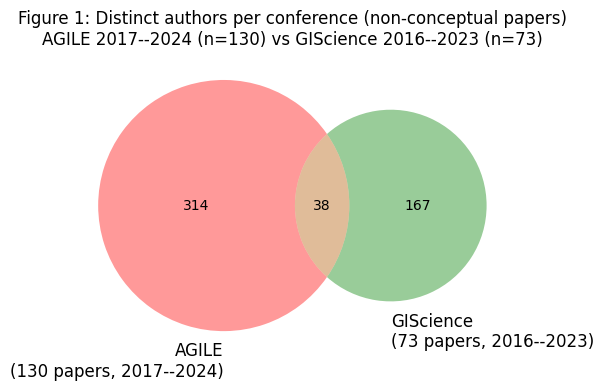

In [196]:
ag_papers = df[df["conf"] == "agile"]
gi_papers = df[df["conf"] == "giscience"]
ag_range = f"{int(ag_papers['year'].min())}--{int(ag_papers['year'].max())}"
gi_range = f"{int(gi_papers['year'].min())}--{int(gi_papers['year'].max())}"

fig, ax = plt.subplots(figsize=(6, 5.4))
venn2(
    [agile_ids, gis_ids],
    set_labels=(
        f"AGILE\n({len(ag_papers)} papers, {ag_range})",
        f"GIScience\n({len(gi_papers)} papers, {gi_range})",
    ),
    ax=ax,
)
ax.set_title(
    f"Figure 1: Distinct authors per conference (non-conceptual papers)\n"
    f"AGILE {ag_range} (n={len(ag_papers)}) vs GIScience {gi_range} (n={len(gi_papers)})"
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1_authorship_venn.png", dpi=150)
fig.savefig(FIG_DIR / "figure1_authorship_venn.pdf")
plt.show()

### A.3 Papers with at least one cross-conference author

For each paper, check whether any of its authors (by identity) also appears on **any** paper at
the other conference series (any year). This is the corpus-wide, time-agnostic count. Reported for
the whole corpus, per-conference, and with identities resolved either via ORCID only (stricter,
more reliable) or via the full identity set including the normalised-name fallback for authors
without an ORCID.

In [197]:
# Map each identity to the set of conferences it appears in.
identity_confs = (
    authors_df.groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)

# ORCID-only identities (drop name-fallback authors entirely).
orcid_identity_confs = (
    authors_df[authors_df["orcid"].notna()]
    .groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)


def paper_cross_conf(paper_df: pd.DataFrame, identity_map: dict) -> pd.Series:
    per_paper = {}
    for paper, grp in paper_df.groupby("paper"):
        this_conf = grp["conf"].iloc[0]
        cross = any(
            (identity_map.get(ident, set()) - {this_conf})
            for ident in grp["identity"]
        )
        per_paper[paper] = cross
    return pd.Series(per_paper, name="cross_conf")


cross_any = paper_cross_conf(authors_df, identity_confs)
cross_orcid = paper_cross_conf(
    authors_df[authors_df["orcid"].notna()], orcid_identity_confs
)

paper_conf = authors_df.groupby("paper")["conf"].first()


def summarise(series: pd.Series, label: str) -> None:
    df_ = series.to_frame().join(paper_conf)
    total = len(df_)
    n_cross = int(df_["cross_conf"].sum())
    print(f"[{label}] overall: {n_cross} / {total} papers have >=1 cross-conference author")
    for conf, sub in df_.groupby("conf"):
        print(
            f"  {conf:>9}: {int(sub['cross_conf'].sum())} / {len(sub)} "
            f"({sub['cross_conf'].mean():.1%})"
        )


summarise(cross_any, "any identity (ORCID + name-fallback)")
print()
summarise(cross_orcid, "ORCID-only")

[any identity (ORCID + name-fallback)] overall: 79 / 203 papers have >=1 cross-conference author
      agile: 46 / 130 (35.4%)
  giscience: 33 / 73 (45.2%)

[ORCID-only] overall: 73 / 199 papers have >=1 cross-conference author
      agile: 43 / 129 (33.3%)
  giscience: 30 / 70 (42.9%)


### A.4 Cross-conference authors -- paper counts per conference

Basic listing: every author identity in both conferences (over the whole corpus) with the number
of papers at each and the list of years they appear in.

In [198]:
overlap_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    overlap_rows.append(
        {
            "name": id_to_name[ident],
            "identity": ident,
            "orcid": ident.split(":", 1)[1] if ident.startswith("orcid:") else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "years": ",".join(str(y) for y in sorted(sub["year"].unique())),
        }
    )

overlap_df = (
    pd.DataFrame(overlap_rows)
    .sort_values(["total_papers", "name"], ascending=[False, True])
    .reset_index(drop=True)
)
display(overlap_df)

,name,identity,orcid,agile_papers,giscience_papers,total_papers,years
0,Ioannis Giannopoulos,orcid:0000-0002-2556-5230,0000-0002-2556-5230,5,6,11,"2016,2018,2019,2020,2021,2023,2024"
1,Martin Raubal,orcid:0000-0001-5951-6835,0000-0001-5951-6835,7,4,11,"2016,2017,2018,2019,2020,2021,2022,2023"
2,Krzysztof Janowicz,orcid:0009-0003-1968-887X,0009-0003-1968-887X,8,2,10,"2017,2018,2019,2020,2021,2022"
3,Henry Martin,orcid:0000-0002-0456-8539,0000-0002-0456-8539,5,3,8,"2018,2019,2020,2021,2022,2023"
4,Dominik Bucher,orcid:0000-0001-9824-5388,0000-0001-9824-5388,3,3,6,"2018,2019,2020,2021"
5,Gengchen Mai,orcid:0000-0002-7818-7309,0000-0002-7818-7309,5,1,6,"2018,2019,2020,2021,2022"
6,Carsten Keßler,orcid:0000-0002-9724-820X,0000-0002-9724-820X,4,1,5,"2016,2018,2019,2020,2022"
7,Jan‐Henrik Haunert,orcid:0000-0001-8005-943X,0000-0001-8005-943X,1,4,5,"2016,2018,2020,2021"
8,Markus Kattenbeck,orcid:0000-0001-6028-0428,0000-0001-6028-0428,1,4,5,"2018,2020,2021"
9,Stephan Winter,orcid:0000-0002-3403-6939,0000-0002-3403-6939,4,1,5,"2017,2019,2020,2023"


### A.5 Cross-conference author statistics -- detailed

For every author identity that appears in **both** conferences (over the whole corpus), show how
many papers they co-authored at each, their first and last year in the corpus, and the span of
years covered. Names in parentheses indicate identities matched via the normalised-name fallback
(no ORCID); treat those rows with extra care because name collisions and name-variant splits are
possible.

In [199]:
cross_stats_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    years = sorted(sub["year"].unique())
    is_orcid = ident.startswith("orcid:")
    display_name = id_to_name[ident] if is_orcid else f"({id_to_name[ident]})"
    cross_stats_rows.append(
        {
            "name": display_name,
            "orcid": ident.split(":", 1)[1] if is_orcid else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "first_year": int(years[0]),
            "last_year": int(years[-1]),
            "year_span": int(years[-1] - years[0]),
            "match": "orcid" if is_orcid else "name",
        }
    )

cross_stats_df = (
    pd.DataFrame(cross_stats_rows)
    .sort_values(
        ["total_papers", "agile_papers", "giscience_papers", "name"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

print(
    f"cross-conference authors: {len(cross_stats_df)} "
    f"(orcid-matched: {(cross_stats_df['match']=='orcid').sum()}, "
    f"name-matched: {(cross_stats_df['match']=='name').sum()})"
)
display(cross_stats_df)

cross_stats_df.to_csv("data/authors-cross-conference.csv", index=False)
print("wrote data/authors-cross-conference.csv")

cross-conference authors: 38 (orcid-matched: 37, name-matched: 1)


,name,orcid,agile_papers,giscience_papers,total_papers,first_year,last_year,year_span,match
0,Martin Raubal,0000-0001-5951-6835,7,4,11,2016,2023,7,orcid
1,Ioannis Giannopoulos,0000-0002-2556-5230,5,6,11,2016,2024,8,orcid
2,Krzysztof Janowicz,0009-0003-1968-887X,8,2,10,2017,2022,5,orcid
3,Henry Martin,0000-0002-0456-8539,5,3,8,2018,2023,5,orcid
4,Gengchen Mai,0000-0002-7818-7309,5,1,6,2018,2022,4,orcid
5,Dominik Bucher,0000-0001-9824-5388,3,3,6,2018,2021,3,orcid
6,Carsten Keßler,0000-0002-9724-820X,4,1,5,2016,2022,6,orcid
7,Stephan Winter,0000-0002-3403-6939,4,1,5,2017,2023,6,orcid
8,Jan‐Henrik Haunert,0000-0001-8005-943X,1,4,5,2016,2021,5,orcid
9,Markus Kattenbeck,0000-0001-6028-0428,1,4,5,2018,2021,3,orcid


wrote data/authors-cross-conference.csv


### A.6 Most-published author identities (any conference)

Top 20 distinct author identities by total number of papers in the corpus, regardless of
conference. Included here for context; cross-conference overlap is in A.1–A.5.

In [200]:
top_overall = (
    authors_df.groupby("identity")
    .agg(
        name=("name", lambda s: Counter(s).most_common(1)[0][0]),
        papers=("paper", "nunique"),
        agile=("conf", lambda s: (s == "agile").sum()),
        giscience=("conf", lambda s: (s == "giscience").sum()),
    )
    .sort_values("papers", ascending=False)
    .head(20)
)
display(top_overall)

,name,papers,agile,giscience
identity,,,,
orcid:0000-0001-5951-6835,Martin Raubal,11,7,4
orcid:0000-0002-2556-5230,Ioannis Giannopoulos,11,5,6
orcid:0009-0003-1968-887X,Krzysztof Janowicz,10,8,2
orcid:0000-0002-0456-8539,Henry Martin,8,5,3
orcid:0000-0002-8514-7858,Bettina Speckmann,6,0,6
orcid:0000-0001-9824-5388,Dominik Bucher,6,3,3
orcid:0000-0002-7818-7309,Gengchen Mai,6,5,1
orcid:0000-0002-6327-3976,Toshihiro Osaragi,6,6,0
orcid:0000-0002-9724-820X,Carsten Keßler,5,4,1


## 9. Part B -- Year-by-year overlap

Part A pooled all years together, so an AGILE author from 2019 and a GIScience author from 2023
could be counted as overlapping. That's the right framing for *community overlap*, but misleading
for *temporal dynamics*: it "inherits" overlap from every other year, and it silently invents
overlap in GIScience off-years (2017, 2019, 2022, 2024), which had no GIScience conference at
all.

Part B constrains the question to a single year at a time: **in year *y*, how many authors
published at both AGILE and GIScience *that year*?** GIScience off-years must be zero by
construction.

### B.1 Shared-year authors and affected papers

In [201]:
# Universe of years present in the corpus.
corpus_years = sorted(authors_df["year"].unique())

# Years each conference actually met.
agile_years = set(authors_df[authors_df["conf"] == "agile"]["year"].unique())
gis_years = set(authors_df[authors_df["conf"] == "giscience"]["year"].unique())
print("AGILE years:    ", sorted(agile_years))
print("GIScience years:", sorted(gis_years))
shared_years = sorted(agile_years & gis_years)
print("Shared years (both conferences met):", shared_years)

# Per-year identity sets, per conference.
yearly_rows = []
for year in corpus_years:
    ag_set = set(
        authors_df[(authors_df["conf"] == "agile") & (authors_df["year"] == year)]["identity"]
    )
    gi_set = set(
        authors_df[(authors_df["conf"] == "giscience") & (authors_df["year"] == year)]["identity"]
    )
    shared = ag_set & gi_set

    ag_papers = authors_df[(authors_df["conf"] == "agile") & (authors_df["year"] == year)]
    gi_papers = authors_df[(authors_df["conf"] == "giscience") & (authors_df["year"] == year)]

    ag_cross_papers = ag_papers[ag_papers["identity"].isin(shared)]["paper"].nunique()
    gi_cross_papers = gi_papers[gi_papers["identity"].isin(shared)]["paper"].nunique()
    ag_total = ag_papers["paper"].nunique()
    gi_total = gi_papers["paper"].nunique()

    yearly_rows.append(
        {
            "year": year,
            "shared_authors": len(shared),
            "agile_papers": ag_total,
            "giscience_papers": gi_total,
            "agile_cross_papers": ag_cross_papers,
            "giscience_cross_papers": gi_cross_papers,
            "agile_cross_share": (ag_cross_papers / ag_total) if ag_total else 0.0,
            "giscience_cross_share": (gi_cross_papers / gi_total) if gi_total else 0.0,
            "both_met": (year in agile_years) and (year in gis_years),
        }
    )

yearly_overlap = pd.DataFrame(yearly_rows)
display(yearly_overlap)

AGILE years:     [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
GIScience years: [np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2023)]
Shared years (both conferences met): [np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2023)]


,year,shared_authors,agile_papers,giscience_papers,agile_cross_papers,giscience_cross_papers,agile_cross_share,giscience_cross_share,both_met
0,2016,0,0,17,0,0,0.000000,0.000000,False
1,2017,0,16,0,0,0,0.000000,0.000000,False
2,2018,2,17,17,1,2,0.058824,0.117647,True
3,2019,0,18,0,0,0,0.000000,0.000000,False
4,2020,6,21,15,3,3,0.142857,0.200000,True
5,2021,3,13,13,2,3,0.153846,0.230769,True
6,2022,0,20,0,0,0,0.000000,0.000000,False
7,2023,1,13,11,1,1,0.076923,0.090909,True
8,2024,0,12,0,0,0,0.000000,0.000000,False


### B.2 Figure 2: Papers with a same-year cross-conference author

Two directions, plotted separately:

- **AGILE to GIScience:** AGILE papers in year *y* for which at least one author *also*
  co-authored a GIScience paper in year *y*.
- **GIScience to AGILE:** GIScience papers in year *y* for which at least one author *also*
  co-authored an AGILE paper in year *y*.

In years without a GIScience conference (2017, 2019, 2022, 2024) both series are zero by
construction.

Styling follows the convention used in the R/Quarto notebooks (Brewer `Set1`, Tufte-style
minimal theme).

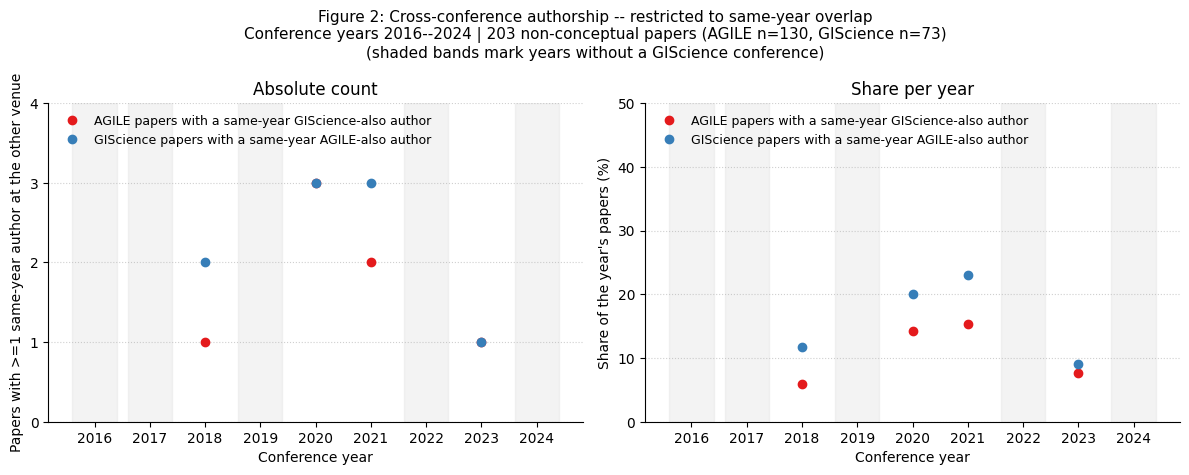

wrote data/authors-cross-conference-yearly.csv


In [202]:
from matplotlib.ticker import MaxNLocator

SET1 = plt.get_cmap("Set1").colors
AG_LABEL = "AGILE papers with a same-year GIScience-also author"
GI_LABEL = "GIScience papers with a same-year AGILE-also author"
dir_colors = {AG_LABEL: SET1[0], GI_LABEL: SET1[1]}

fig, (ax_n, ax_p) = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

# Drop years where the structural overlap is undefined (one of the conferences
# did not run that year). The grey bands still mark those years explicitly.
yo = yearly_overlap[yearly_overlap["both_met"]].sort_values("year")
off_years = [
    int(y) for y in sorted(yearly_overlap["year"])
    if not yearly_overlap.loc[yearly_overlap["year"] == y, "both_met"].iloc[0]
]

# Markers only -- no connecting lines, since adjacent valid years can be far apart.
ax_n.plot(yo["year"], yo["agile_cross_papers"],
          marker="o", linestyle="", color=dir_colors[AG_LABEL], label=AG_LABEL)
ax_n.plot(yo["year"], yo["giscience_cross_papers"],
          marker="o", linestyle="", color=dir_colors[GI_LABEL], label=GI_LABEL)

ax_p.plot(yo["year"], yo["agile_cross_share"] * 100,
          marker="o", linestyle="", color=dir_colors[AG_LABEL], label=AG_LABEL)
ax_p.plot(yo["year"], yo["giscience_cross_share"] * 100,
          marker="o", linestyle="", color=dir_colors[GI_LABEL], label=GI_LABEL)

all_years = sorted(yearly_overlap["year"].unique())
for ax in (ax_n, ax_p):
    for y in off_years:
        ax.axvspan(y - 0.4, y + 0.4, color="lightgrey", alpha=0.25, zorder=0)
    ax.set_xlabel("Conference year")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", linestyle=":", alpha=0.6)
    ax.set_xticks(all_years)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

ax_n.set_ylim(0, 4)
ax_n.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_n.set_ylabel("Papers with >=1 same-year author at the other venue")
ax_n.set_title("Absolute count")

ax_p.set_ylim(0, 50)
ax_p.set_ylabel("Share of the year's papers (%)")
ax_p.set_title("Share per year")

# Subtitle with corpus extent (computational == non-conceptual papers).
year_min = int(df["year"].min())
year_max = int(df["year"].max())
subtitle = (
    f"Conference years {year_min}--{year_max} | "
    f"{len(df)} non-conceptual papers "
    f"(AGILE n={(df['conf']=='agile').sum()}, GIScience n={(df['conf']=='giscience').sum()})"
)
fig.suptitle(
    "Figure 2: Cross-conference authorship -- restricted to same-year overlap\n"
    + subtitle
    + "\n(shaded bands mark years without a GIScience conference)",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure2_authorship_cross_conf_timeline.png", dpi=150)
fig.savefig(FIG_DIR / "figure2_authorship_cross_conf_timeline.pdf")
plt.show()

yearly_overlap.to_csv("data/authors-cross-conference-yearly.csv", index=False)
print("wrote data/authors-cross-conference-yearly.csv")

## 10. Reproducibility for cross-conference-author papers

Two complementary views of whether papers authored by people who publish at *both*
AGILE and GIScience track the overall corpus trend, lead it, or lag behind. Throughout
this section a paper counts as *cross-author* if at least one of its authors (resolved
identity, pooling all years in the corpus) also appears on at least one paper at the
other conference series -- the time-agnostic, direction-pooled definition from Part A
(section 8). Direction (AGILE-to-GIScience vs. GIScience-to-AGILE) is deliberately
ignored.

### 10.1 Per-year reproducibility-level distribution

A bubble-matrix plot per criterion (*Input Data*, *Methods*, *Results*): each year
shows one column of four circles (one per UDAO level on the y-axis), with circle area
proportional to the number of papers at that level in that year. Both subsets below
**pool AGILE and GIScience papers** (a year's column therefore combines all papers
published at either conference that year). Two subsets are overlaid on the same axes:

- **Grey hollow outlines**: all non-conceptual papers in the corpus (both AGILE and
  GIScience pooled) -- the "overall" backdrop.
- **Red filled circles**: cross-author papers only, again pooled across the two
  conferences. Because cross-author papers are a strict subset of overall, the red
  circle is always at or inside the grey one; the visible gap is the "non-cross-author"
  share for that (year, level) cell.

Higher rows (A, O) mark more reproducible papers. Reading the plot vertically in each
year shows how that year's papers are distributed across levels; reading horizontally
along a level shows how that level's headcount changes over time. The per-(year, level,
subset) counts are also persisted to
[`data/cross-author-reprolevels-yearly.csv`](data/cross-author-reprolevels-yearly.csv)
for downstream use.

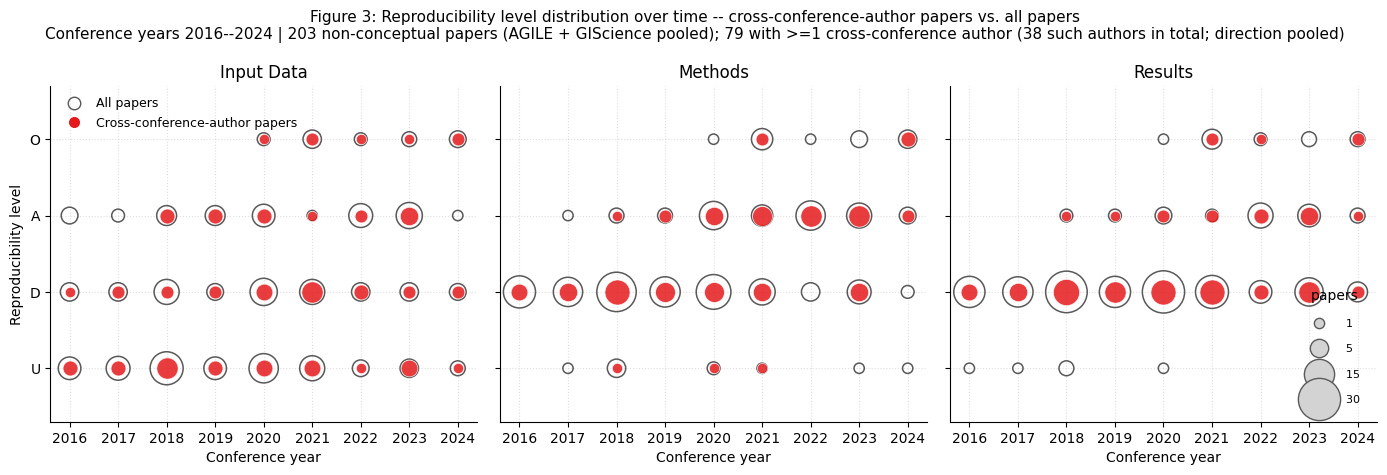

wrote data/cross-author-reprolevels-yearly.csv


In [203]:
from matplotlib.lines import Line2D

LEVEL_LABELS = ["U", "D", "A", "O"]  # y-axis: bottom (U) -> top (O), increasing reproducibility
CRITERIA = ["data", "methods", "results"]
CRIT_TITLE = {"data": "Input Data", "methods": "Methods", "results": "Results"}

# Cross-conference identities (any year; direction pooled, matching Part A).
cross_ids = (
    set(authors_df[authors_df["conf"] == "agile"]["identity"]) &
    set(authors_df[authors_df["conf"] == "giscience"]["identity"])
)
papers_with_cross = set(authors_df[authors_df["identity"].isin(cross_ids)]["paper"])

repro = df[["paper", "conf", "year"] + [f"consolidated_{c}" for c in CRITERIA]].copy()
repro["is_cross"] = repro["paper"].isin(papers_with_cross)


def counts_by_year_level(sub: pd.DataFrame, crit: str) -> pd.DataFrame:
    if len(sub) == 0:
        return pd.DataFrame(columns=["year", "level", "n"])
    return (
        sub.groupby(["year", f"consolidated_{crit}"]).size()
        .reset_index(name="n")
        .rename(columns={f"consolidated_{crit}": "level"})
    )


SET1 = plt.get_cmap("Set1").colors
COLOR_CROSS = SET1[0]
COLOR_OVERALL = "0.35"
SIZE_BASE = 25          # base marker area (pt^2) so a 1-paper dot is still visible
SIZE_PER_PAPER = 30     # additional area per paper (linear in count)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
years = sorted(repro["year"].unique())
for ax, crit in zip(axes, CRITERIA):
    overall = counts_by_year_level(repro, crit)
    cross   = counts_by_year_level(repro[repro["is_cross"]], crit)

    # Grey hollow outline = all papers. Drawn first, underneath.
    for _, r in overall.iterrows():
        y = LEVEL_LABELS.index(r["level"])
        ax.scatter(r["year"], y, s=SIZE_BASE + SIZE_PER_PAPER * r["n"],
                   facecolor="none", edgecolor=COLOR_OVERALL, linewidth=1.1, zorder=3)
    # Red filled = cross-author subset. Always <= the grey outline at the same cell.
    for _, r in cross.iterrows():
        y = LEVEL_LABELS.index(r["level"])
        ax.scatter(r["year"], y, s=SIZE_BASE + SIZE_PER_PAPER * r["n"],
                   facecolor=COLOR_CROSS, edgecolor="white", linewidth=0.5,
                   alpha=0.85, zorder=5)

    ax.set_title(CRIT_TITLE[crit])
    ax.set_xlabel("Conference year")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.set_xticks(years)
    ax.set_ylim(-0.7, 3.7)

axes[0].set_yticks(range(4))
axes[0].set_yticklabels(LEVEL_LABELS)
axes[0].set_ylabel("Reproducibility level")

subset_hints = [
    Line2D([0], [0], marker="o", linestyle="", markersize=9,
           markerfacecolor="none", markeredgecolor=COLOR_OVERALL,
           label="All papers"),
    Line2D([0], [0], marker="o", linestyle="", markersize=9,
           markerfacecolor=COLOR_CROSS, markeredgecolor="white",
           label="Cross-conference-author papers"),
]
axes[0].legend(handles=subset_hints, loc="upper left", fontsize=9, frameon=False)

size_hints = [
    Line2D([0], [0], marker="o", linestyle="", markersize=(SIZE_BASE + SIZE_PER_PAPER * n) ** 0.5,
           markerfacecolor="lightgrey", markeredgecolor=COLOR_OVERALL, label=f"  {n}")
    for n in (1, 5, 15, 30)
]
axes[-1].legend(handles=size_hints, loc="lower right", fontsize=8, frameon=False,
                title="papers", labelspacing=1.4, borderpad=1.0)

subtitle = (
    f"Conference years {int(repro['year'].min())}--{int(repro['year'].max())} | "
    f"{len(repro)} non-conceptual papers (AGILE + GIScience pooled); "
    f"{int(repro['is_cross'].sum())} with >=1 cross-conference author "
    f"({len(cross_ids)} such authors in total; direction pooled)"
)
fig.suptitle(
    "Figure 3: Reproducibility level distribution over time -- cross-conference-author papers vs. all papers\n"
    + subtitle, fontsize=11,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure3_authorship_cross_author_reprolevels.png", dpi=150)
fig.savefig(FIG_DIR / "figure3_authorship_cross_author_reprolevels.pdf")
plt.show()

# Persist per-(year, level, subset) counts for downstream use.
rows = []
for crit in CRITERIA:
    for subset_name, sub in (("all-papers", repro), ("cross-author", repro[repro["is_cross"]])):
        c = counts_by_year_level(sub, crit)
        for _, r in c.iterrows():
            rows.append({"criterion": CRIT_TITLE[crit], "subset": subset_name,
                         "year": int(r["year"]), "level": r["level"], "n": int(r["n"])})
pd.DataFrame(rows).to_csv("data/cross-author-reprolevels-yearly.csv", index=False)
print("wrote data/cross-author-reprolevels-yearly.csv")

### 10.2 Absolute change in % *HIGH* across the intervention

Mirrors the gt-table *"GIScience vs AGILE: Absolute change in percentage points"* from
[`03_results_reprolevels.qmd`](03_results_reprolevels.qmd) (manuscript Table showing the
pre-vs-post intervention shift), but adds a second "cross-author only" view beside each
conference so we can ask: **are cross-conference authors leading the improvement, or
lagging behind?**

**Definition.** Each criterion is aggregated to a binary level: `HIGH = {A, O}` (the
two higher reproducibility levels) vs. `LOW = {U, D}`. For each conference the corpus
is split at the intervention year: *pre* = `year < 2020`, *post* = `year > 2020`; 2020
is excluded (transition year -- the AGILE guidelines were optional). The statistic is
the per-conference per-criterion delta `%HIGH(post) - %HIGH(pre)`, in percentage points.

**Reading the table.** For each conference we report the delta for **all papers** (as
in the original table) and for the **cross-author subset** side by side. The last
column, *lead/lag*, is `delta(cross) - delta(all)`: positive means cross-authors
are pulling the curve up faster than the overall corpus on that criterion; negative
means they trail. Sample sizes (`n_pre`, `n_post`) are reported because the cross-author
subset is small for GIScience pre (13 papers).

In [204]:
# Section 10.2: absolute change in %HIGH from pre- to post-intervention,
# for all papers vs cross-author papers only. Mirrors the table in
# 03_results_reprolevels.qmd but with the cross-author subset alongside.

INTERVENTION_YEAR = 2020  # 2020 is excluded (AGILE transition year)
HIGH_LEVELS = {"A", "O"}


def pct_high(sub: pd.DataFrame, col: str) -> tuple[float, int]:
    """Return (%HIGH, N) for a subset of papers on one consolidated_{crit} column."""
    if len(sub) == 0:
        return float("nan"), 0
    n_high = int(sub[col].isin(HIGH_LEVELS).sum())
    return n_high / len(sub), len(sub)


rows = []
for conf in ("giscience", "agile"):
    base = df[df["conf"] == conf]
    for subset_name, subset in (
        ("all papers", base),
        ("cross-author only", base[base["paper"].isin(papers_with_cross)]),
    ):
        pre  = subset[subset["year"] < INTERVENTION_YEAR]
        post = subset[subset["year"] > INTERVENTION_YEAR]
        for crit in CRITERIA:
            col = f"consolidated_{crit}"
            p_pre,  n_pre  = pct_high(pre,  col)
            p_post, n_post = pct_high(post, col)
            rows.append({
                "criterion": CRIT_TITLE[crit],
                "conf": conf.upper(),
                "subset": subset_name,
                "pct_HIGH_pre":  round(p_pre  * 100, 1) if n_pre  else float("nan"),
                "n_pre":  n_pre,
                "pct_HIGH_post": round(p_post * 100, 1) if n_post else float("nan"),
                "n_post": n_post,
                "delta_pp": round((p_post - p_pre) * 100, 1),
            })
delta_tbl = pd.DataFrame(rows)

# Side-by-side pivot matching the manuscript's table layout, with cross-author column added.
pivot = (
    delta_tbl.set_index(["criterion", "conf", "subset"])["delta_pp"]
    .unstack(["conf", "subset"])
    .reindex(["Input Data", "Methods", "Results"])
    [[("GISCIENCE", "all papers"), ("GISCIENCE", "cross-author only"),
      ("AGILE",     "all papers"), ("AGILE",     "cross-author only")]]
)
pivot.columns = pd.MultiIndex.from_tuples(
    [("GIScience", "all"), ("GIScience", "cross"),
     ("AGILE",     "all"), ("AGILE",     "cross")],
    names=["conference", "subset"],
)
print("Absolute change in %HIGH across the intervention (pp):")
print(pivot.to_string())

# Lead/lag column: cross - all (per conference x criterion).
lead_lag = (
    delta_tbl.set_index(["criterion", "conf", "subset"])["delta_pp"]
    .unstack("subset")
    .assign(**{"lead/lag (pp)": lambda d: d["cross-author only"] - d["all papers"]})
    .reindex(["Input Data", "Methods", "Results"], level=0)
    [["all papers", "cross-author only", "lead/lag (pp)"]]
    .round(1)
)
print()
print("Lead/lag of the cross-author subset (positive = leading, negative = lagging):")
print(lead_lag.to_string())

# Sample sizes for the cross-author subset, for honesty about small-N.
print()
print("Sample sizes (cross-author subset only):")
sizes = (
    delta_tbl[delta_tbl["subset"] == "cross-author only"]
    [["criterion", "conf", "n_pre", "n_post"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(sizes.to_string(index=False))

# Persist for the manuscript / other consumers.
delta_tbl.to_csv("data/cross-author-intervention-delta.csv", index=False)
print()
print("wrote data/cross-author-intervention-delta.csv")

Absolute change in %HIGH across the intervention (pp):
conference GIScience       AGILE      
subset           all cross   all cross
criterion                             
Input Data      -3.9  -2.9  33.6  29.5
Methods         42.9  43.8  58.9  72.2
Results         25.0  31.2  45.6  37.5

Lead/lag of the cross-author subset (positive = leading, negative = lagging):
subset                all papers  cross-author only  lead/lag (pp)
criterion  conf                                                   
Input Data AGILE            33.6               29.5           -4.1
           GISCIENCE        -3.9               -2.9            1.0
Methods    AGILE            58.9               72.2           13.3
           GISCIENCE        42.9               43.8            0.9
Results    AGILE            45.6               37.5           -8.1
           GISCIENCE        25.0               31.2            6.2

Sample sizes (cross-author subset only):
 criterion      conf  n_pre  n_post
Input Data GISCIEN

## 11. Cross-group author overlap (non-independence check)

The main hypothesis testing in [`04_results_hypotheses.ipynb`](04_results_hypotheses.ipynb)
(Mann-Whitney-U, rank-biserial effect sizes, Fisher exact tests; manuscript Tables 4-7)
treats the four groups as independent samples:

- `agile_pre`      -- AGILE papers,     `year < 2020`
- `agile_post`     -- AGILE papers,     `year > 2020`
- `giscience_pre`  -- GIScience papers, `year < 2020`
- `giscience_post` -- GIScience papers, `year > 2020`

Papers from 2020 are excluded, matching the rest of the analysis (AGILE transition year).

Independence assumes that papers in one group do not share authors with papers in
another group (or within the same group). When the same person contributes to multiple
papers across these groups, the groups are correlated and the apparent effect size of
any pre-vs-post or AGILE-vs-GIScience comparison can be inflated.

**This section is a first iteration**: for every author with `>= 2` papers
(irrespective of whether those papers cross a conference or time-period boundary) we
list each of their papers and which of the four groups it belongs to, together with
the reproducibility level recorded for each criterion. No aggregation -- just the raw
values of the categorical variables that feed the main analysis. The full table is
written to
[`data/cross-group-overlap-multipaper-authors.csv`](data/cross-group-overlap-multipaper-authors.csv)
for inspection. Aggregations (per-group counts, overlap matrices, upset-style plots)
can build on this raw view in later iterations.

In [205]:
# Section 11: raw view of author overlap across the four analytical groups.

INTERVENTION_YEAR = 2020


def _group_of(year: int, conf: str) -> str | None:
    if year < INTERVENTION_YEAR:
        return f"{conf}_pre"
    if year > INTERVENTION_YEAR:
        return f"{conf}_post"
    return None  # 2020 excluded


# Start from authors_df (one row per author-paper) and attach the group label.
grouped = authors_df.copy()
grouped["group"] = [
    _group_of(int(y), c) for y, c in zip(grouped["year"], grouped["conf"])
]
grouped = grouped.dropna(subset=["group"])

# Keep only authors with >= 2 papers (pooling across the 4 groups).
papers_per_author = grouped.groupby("identity")["paper"].nunique()
multi_ids = papers_per_author[papers_per_author > 1].index
multi = grouped[grouped["identity"].isin(multi_ids)].copy()

# Attach reproducibility levels from df so the raw categorical values are visible.
multi = multi.merge(
    df[["paper", "consolidated_data", "consolidated_methods", "consolidated_results"]],
    on="paper", how="left",
)

multi = multi.sort_values(["identity", "year", "conf", "paper"]).reset_index(drop=True)

# Headline numbers (these are orientation summary stats, NOT aggregations of the
# categorical variables the user asked to keep raw).
n_authors = multi["identity"].nunique()
n_rows = len(multi)
groups_per_author = (
    multi.groupby("identity")["group"].nunique().value_counts().sort_index()
)
print(f"multi-paper authors: {n_authors}")
print(f"author-paper rows for those authors: {n_rows}")
print()
print("count of authors by number of distinct groups they appear in:")
for k, v in groups_per_author.items():
    print(f"  appears in {k} group(s): {v} author(s)")
print()
print("papers per group (restricted to multi-paper authors):")
print(multi.groupby("group")["paper"].nunique().to_string())

# Persist the full raw table.
cols = ["identity", "name", "group", "conf", "year", "paper",
        "consolidated_data", "consolidated_methods", "consolidated_results"]
out_path = Path("data/cross-group-overlap-multipaper-authors.csv")
multi[cols].to_csv(out_path, index=False)
print()
print(f"wrote {out_path} ({n_rows} rows)")

# Inline display of the full table, one row per author-paper.
with pd.option_context("display.max_rows", None, "display.max_colwidth", 60):
    display(multi[cols])

multi-paper authors: 73
author-paper rows for those authors: 213

count of authors by number of distinct groups they appear in:
  appears in 1 group(s): 21 author(s)
  appears in 2 group(s): 43 author(s)
  appears in 3 group(s): 7 author(s)
  appears in 4 group(s): 2 author(s)

papers per group (restricted to multi-paper authors):
group
agile_post        42
agile_pre         25
giscience_post    20
giscience_pre     21

wrote data/cross-group-overlap-multipaper-authors.csv (213 rows)


,identity,name,group,conf,year,paper,consolidated_data,consolidated_methods,consolidated_results
0,name:arthur goethem van,Arthur van Goethem,giscience_pre,giscience,2016,giscience_2016_019,U,D,D
1,name:arthur goethem van,Arthur van Goethem,giscience_post,giscience,2021,giscience_2021_024,U,A,D
2,name:ashwin shashidharan,Ashwin Shashidharan,giscience_pre,giscience,2016,giscience_2016_011,U,D,D
3,name:ashwin shashidharan,Ashwin Shashidharan,giscience_pre,giscience,2018,giscience_2018_016,U,D,D
4,orcid:0000-0001-5087-8776,Auriol Degbelo,agile_post,agile,2021,agile_2021_007,O,O,O
5,orcid:0000-0001-5087-8776,Auriol Degbelo,agile_post,agile,2024,agile_2024_006,U,A,A
6,orcid:0000-0001-5951-6835,Martin Raubal,giscience_pre,giscience,2016,giscience_2016_021,U,D,D
7,orcid:0000-0001-5951-6835,Martin Raubal,agile_pre,agile,2017,agile_2017_017,U,D,D
8,orcid:0000-0001-5951-6835,Martin Raubal,agile_pre,agile,2018,agile_2018_015,U,D,D
9,orcid:0000-0001-5951-6835,Martin Raubal,giscience_pre,giscience,2018,giscience_2018_015,U,D,D


### 11.2 Figure: reproducibility by criterion, faceted by group

Small multiples -- one panel per analytical group (`agile_pre`, `agile_post`,
`giscience_pre`, `giscience_post`). Each point is **one distinct paper** in the
group, positioned at (reproducibility criterion, achieved level) with uniform random
jitter on both axes so overlapping points become visible. Two subsets are overlaid:

- **Toned-down grey** -- papers whose authors do *not* publish in any of the other
  three groups. Drawn underneath as a low-contrast backdrop so the eye sees the
  shape of the full analytical group. All grey dots have the same size.
- **Coloured (one colour per group)** -- papers with at least one "cross-group
  author", i.e. an author who also publishes in one of the other three groups.
  Drawn on top so the subset that drives non-independence stands out.
  **Circle area scales with the number of cross-group authors on that paper**,
  so papers with many such authors are visually heavier -- they are the strongest
  source of non-independence.

Each panel title reports the number of cross-group-author papers together with the
total number of papers in the analytical group and the resulting percentage -- a
direct read-out of how much non-independent signal each group carries into the main
pre-vs-post and AGILE-vs-GIScience comparisons.

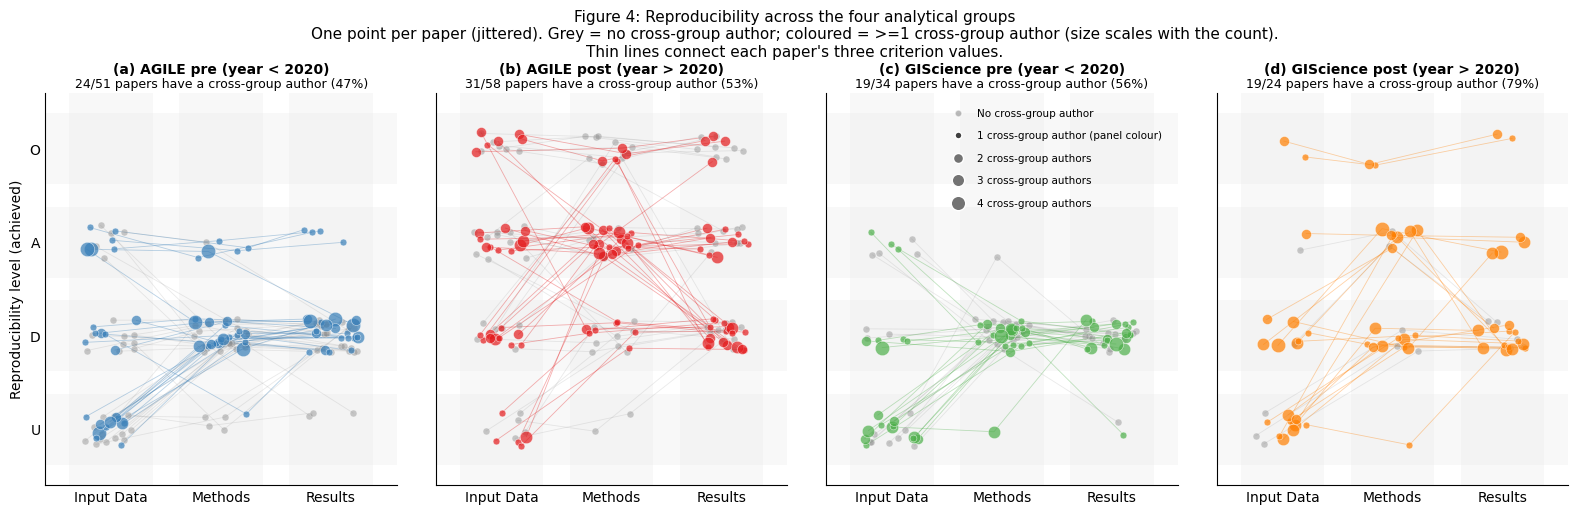

In [206]:
# Section 11.2: jittered small multiples of reproducibility across the four groups.
# One point per distinct paper per group; two overlays:
#   - grey (backdrop):   papers without a cross-group author (uniform size)
#   - coloured (on top): papers with >=1 cross-group author (size ~ # cross-group authors)
# Thin lines connect each paper's three criterion points across the x-axis.
# Broad horizontal and vertical bands replace grid lines to show that jittered points
# within the same band share the same categorical value.
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

GROUPS = ["agile_pre", "agile_post", "giscience_pre", "giscience_post"]
GROUP_TITLES = {
    "agile_pre":      "AGILE pre (year < 2020)",
    "agile_post":     "AGILE post (year > 2020)",
    "giscience_pre":  "GIScience pre (year < 2020)",
    "giscience_post": "GIScience post (year > 2020)",
}
CRITERIA = ["data", "methods", "results"]
CRIT_LABELS = {"data": "Input Data", "methods": "Methods", "results": "Results"}
LEVEL_LABELS = ["U", "D", "A", "O"]  # bottom -> top, increasing reproducibility

SET1 = plt.get_cmap("Set1").colors
GROUP_COLORS = {
    "agile_pre":      SET1[1],  # blue   (AGILE pre)
    "agile_post":     SET1[0],  # red    (AGILE post)
    "giscience_pre":  SET1[2],  # green  (GIScience pre)
    "giscience_post": SET1[4],  # orange (GIScience post)
}
COLOR_NONCROSS = "0.55"  # slightly stronger grey for non-cross papers (was 0.7)
BAND_COLOR = "0.92"      # light grey for the categorical bands
SIZE_BASE = 24
SIZE_PER_AUTHOR = 28

rng = np.random.default_rng(20260416)
X_JIT = 0.25
Y_JIT = 0.18
BAND_HALF = 0.38  # half-width of each band (just under 0.5 so adjacent bands don't touch)

# Cross-group authors = identities appearing in >= 2 of the 4 groups.
author_groups = grouped.groupby("identity")["group"].agg(lambda s: set(s))
crossgroup_ids = set(author_groups[author_groups.map(len) >= 2].index)

crossgroup_author_counts = (
    grouped[grouped["identity"].isin(crossgroup_ids)]
    .groupby(["group", "paper"])["identity"]
    .nunique()
    .rename("n_crossgroup_authors")
    .reset_index()
)

all_group_papers = (
    grouped[["group", "paper"]].drop_duplicates()
    .merge(
        df[["paper", "consolidated_data", "consolidated_methods",
            "consolidated_results"]],
        on="paper", how="left",
    )
    .merge(crossgroup_author_counts, on=["group", "paper"], how="left")
)
all_group_papers["n_crossgroup_authors"] = (
    all_group_papers["n_crossgroup_authors"].fillna(0).astype(int)
)
all_group_papers["is_cross"] = all_group_papers["n_crossgroup_authors"] > 0
group_totals = all_group_papers.groupby("group")["paper"].nunique()

PANEL_LABELS = {g: chr(ord("a") + i) for i, g in enumerate(GROUPS)}

fig, axes = plt.subplots(1, 4, figsize=(16, 5.2), sharey=True)
for ax, group in zip(axes, GROUPS):
    sub_all = all_group_papers[all_group_papers["group"] == group]
    sub_non = sub_all[~sub_all["is_cross"]]
    sub_cross = sub_all[sub_all["is_cross"]]
    n_total = int(group_totals.get(group, 0))
    n_cross = len(sub_cross)
    pct = (n_cross / n_total * 100) if n_total else 0.0

    # Draw categorical bands (alternating horizontal for levels, vertical for criteria).
    for yi in range(len(LEVEL_LABELS)):
        ax.add_patch(Rectangle(
            (-0.6, yi - BAND_HALF), len(CRITERIA) - 0.4 + 0.6, 2 * BAND_HALF,
            facecolor=BAND_COLOR, edgecolor="none", alpha=0.35, zorder=0,
        ))
    for xi in range(len(CRITERIA)):
        ax.add_patch(Rectangle(
            (xi - BAND_HALF, -0.6), 2 * BAND_HALF, len(LEVEL_LABELS) - 0.4 + 0.6,
            facecolor=BAND_COLOR, edgecolor="none", alpha=0.35, zorder=0,
        ))

    # Pre-compute jittered positions per paper across all 3 criteria.
    def _jitter_subset(sub, rng):
        coords = {}
        for _, row in sub.iterrows():
            pts = []
            for xi, crit in enumerate(CRITERIA):
                val = row[f"consolidated_{crit}"]
                if pd.isna(val) or val not in LEVEL_LABELS:
                    pts.append(None)
                else:
                    yi = LEVEL_LABELS.index(val)
                    x = xi + rng.uniform(-X_JIT, X_JIT)
                    y = yi + rng.uniform(-Y_JIT, Y_JIT)
                    pts.append((x, y))
            coords[row["paper"]] = pts
        return coords

    coords_non = _jitter_subset(sub_non, rng)
    coords_cross = _jitter_subset(sub_cross, rng)

    # Connecting lines first (underneath dots).
    for coords, color, alpha_line in [
        (coords_non,   COLOR_NONCROSS,        0.18),
        (coords_cross, GROUP_COLORS[group],    0.35),
    ]:
        for paper, pts in coords.items():
            valid = [(x, y) for p in pts if p is not None for x, y in [p]]
            if len(valid) >= 2:
                xs, ys = zip(*valid)
                ax.plot(xs, ys, color=color, linewidth=0.6, alpha=alpha_line, zorder=1)

    # Scatter: grey backdrop (non-cross), uniform size.
    for paper, pts in coords_non.items():
        for pt in pts:
            if pt is None:
                continue
            ax.scatter(pt[0], pt[1], s=SIZE_BASE, alpha=0.45,
                       facecolor=COLOR_NONCROSS, edgecolor="white", linewidth=0.3,
                       zorder=2)

    # Scatter: coloured foreground (cross), size scaled by count.
    for paper, pts in coords_cross.items():
        n_auth = int(sub_cross.loc[sub_cross["paper"] == paper, "n_crossgroup_authors"].iloc[0])
        s = SIZE_BASE + SIZE_PER_AUTHOR * (n_auth - 1)
        for pt in pts:
            if pt is None:
                continue
            ax.scatter(pt[0], pt[1], s=s, alpha=0.7,
                       facecolor=GROUP_COLORS[group], edgecolor="white", linewidth=0.4,
                       zorder=4)

    label = PANEL_LABELS[group]
    ax.set_title(
        f"({label}) {GROUP_TITLES[group]}",
        fontsize=10, fontweight="bold", pad=14,
    )
    ax.text(
        0.5, 1.005,
        f"{n_cross}/{n_total} papers have a cross-group author ({pct:.0f}%)",
        transform=ax.transAxes, fontsize=9, ha="center", va="bottom",
    )

    ax.set_xticks(range(len(CRITERIA)))
    ax.set_xticklabels([CRIT_LABELS[c] for c in CRITERIA])
    ax.set_xlim(-0.6, len(CRITERIA) - 0.4)
    ax.set_ylim(-0.6, len(LEVEL_LABELS) - 0.4)
    ax.tick_params(axis="both", length=0)  # remove tick marks
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_yticks(range(len(LEVEL_LABELS)))
axes[0].set_yticklabels(LEVEL_LABELS)
axes[0].set_ylabel("Reproducibility level (achieved)")

# Legend: grey = non-cross; coloured = cross; size key.
legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=SIZE_BASE**0.5,
           markerfacecolor=COLOR_NONCROSS, markeredgecolor="white",
           alpha=0.6, label="No cross-group author"),
    Line2D([0], [0], marker="o", linestyle="", markersize=SIZE_BASE**0.5,
           markerfacecolor="0.25", markeredgecolor="white",
           label="1 cross-group author (panel colour)"),
]
for n_auth in (2, 3, 4):
    legend_handles.append(
        Line2D([0], [0], marker="o", linestyle="",
               markersize=(SIZE_BASE + SIZE_PER_AUTHOR * (n_auth - 1))**0.5,
               markerfacecolor="0.45", markeredgecolor="white",
               label=f"{n_auth} cross-group authors"),
    )
axes[2].legend(handles=legend_handles, loc="upper right", fontsize=7.5,
               frameon=False, labelspacing=1.2, borderpad=1.0)

fig.suptitle(
    "Figure 4: Reproducibility across the four analytical groups\n"
    "One point per paper (jittered). Grey = no cross-group author; "
    "coloured = >=1 cross-group author (size scales with the count).\n"
    "Thin lines connect each paper's three criterion values.",
    fontsize=11,
)
fig.tight_layout()
fig.subplots_adjust(top=0.82)
fig.savefig(FIG_DIR / "figure4_crossgroup_overlap_reprolevels.png", dpi=150)
fig.savefig(FIG_DIR / "figure4_crossgroup_overlap_reprolevels.pdf")
plt.show()

## 12. Persist enriched outputs

The authoritative per-author-per-paper table is written to
[`data-clean/authors.csv`](data-clean/authors.csv) -- this is the only "final" curated
table for downstream use, and its schema is documented in
[`data-clean/README.md`](data-clean/README.md).

Derived / aggregate views, useful for the manuscript and quick re-use but trivially
regenerable from `authors.csv`, land in [`data/`](data/):

- `authors-overlap.csv`            -- cross-conference authors with paper counts and years
- `authors-cross-conference.csv`   -- detailed cross-conference statistics (year span etc.)
- `authors-cross-conference-yearly.csv` -- per-year same-year overlap counts
- `authors-title-verification.csv` -- DOI-vs-OpenAlex title sanity check (debug artifact)

In [207]:
# Authoritative table: one row per author-paper.
authors_df.to_csv("data-clean/authors.csv", index=False)
print("wrote data-clean/authors.csv (authoritative)")

# Derived / aggregate views (regenerable from authors.csv).
overlap_df.to_csv("data/authors-overlap.csv", index=False)
verify_df.to_csv("data/authors-title-verification.csv", index=False)
print("wrote data/authors-overlap.csv")
print("wrote data/authors-title-verification.csv")

wrote data-clean/authors.csv (authoritative)
wrote data/authors-overlap.csv
wrote data/authors-title-verification.csv
